# Whose Sharpe Is It? — a quantitative teardown \U0001F52C
### Exact conversion · the variance identity · drift/variance/rate decomposition · hedge carry

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Partial](https://img.shields.io/badge/Tradability-Partial-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Three channels
move a Sharpe ratio when you change currency, and they have completely different half-lives.
Separating them is the study.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from whosesharpe import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
fx_rets = {k: rets[v].dropna() for k, v in data.FX.items()
           if v in rets.columns and rets[v].notna().sum() > 1000}
asset = rets[data.ASSET].dropna()
common = asset.index
for f in fx_rets.values():
    common = common.intersection(f.index)
asset = asset.reindex(common).dropna()
usd_rf = rets[data.CASH].reindex(asset.index).fillna(0.0)
fx_rets = {k: v.reindex(asset.index).dropna() for k, v in fx_rets.items()}
tbl = st.sharpe_by_currency(asset, fx_rets, usd_rf)
print(f"as-of {data.AS_OF} | {data.ASSET}, {asset.index[0].date()} -> "
      f"{asset.index[-1].date()} ({len(asset) / 252:.1f} years)")
print(tbl[["cagr", "vol", "rf_ann", "sharpe"]].round(4).to_string())

as-of 2026-06-30 | SPY, 2007-02-14 -> 2026-06-30 (19.3 years)
           cagr    vol  rf_ann  sharpe
currency                              
USD      0.1089 0.1969  0.0134  0.4554
EUR      0.1144 0.1961  0.0229  0.4346
GBP      0.1230 0.1913  0.0271  0.4651
JPY      0.1310 0.2476  0.0310  0.3714
CHF      0.0901 0.2217  0.0090  0.3479
AUD      0.0959 0.1638  0.0193  0.4413
CAD      0.1142 0.1721  0.0217  0.5021


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Weak | Over 19 years, SPY delivered a Sharpe of **0.46** to a dollar-based investor and anywhere from **0.35** (CHF) to **0.50** (CAD) to investors based elsewhere — a spread of **0.15**, on the identical shares. Three separate channels do the work and they behave differently. The **variance** channel is mechanical: adding a currency leg raised volatility from 19.7% to a median 19.4% because var(a−c) = var(a) + var(c) − 2cov, and the median correlation between SPY and these currencies was only +0.27. The **drift** channel is luck: the dollar happened to move. The **rate** channel is the one nobody adjusts for — each investor's cash leg is their own, and using the US bill rate for everyone (the standard shortcut) biases every high-rate country's Sharpe downward. Across 5 assets the currency moved at least one pair's ranking by **1 places**. |
| **Tradability** | Partial | Hedging is priced here rather than assumed, because a rolling forward hedge earns the **interest-rate differential** and not zero — selling dollars forward while US rates exceed yours costs you the gap, which is the charge hedged share classes pass on quietly. After that charge, a full hedge raised the Sharpe for **50%** of the currencies here, by a median -0.00. The variance-minimising ratio is not 1.0 either: its median across currencies is **1.57**, because SPY itself co-moves with risk-off currencies, so a full hedge is close to right. The practical reading is that the hedge buys volatility reduction reliably and return unreliably — which is the right way round for a long-horizon holder and the wrong way round for anyone hoping the hedge pays for itself. |

> \U0001F4A1 **In plain words.** One of the three channels is arithmetic, one is a coin flip, and
> one is a rate differential nobody adjusts for. They are usually reported as a single number.

## 1 · Hypotheses

- **H₁.** The Sharpe of one asset differs materially across home currencies.
- **H₂ (variance).** Volatility rises for every currency whose correlation with the asset is
  below `σ_c / (2σ_a)`, exactly as `var(a−c) = var(a) + var(c) − 2cov` requires.
- **H₃ (rates).** Using the US risk-free rate for all investors biases high-rate countries'
  Sharpe downward by a measurable amount.
- **H₄ (ranking).** The currency does more than shift every Sharpe equally — it reorders assets.
- **H₅ (hedging).** After charging the interest-rate differential, hedging raises the Sharpe for
  most currencies, and the variance-minimising ratio is not 1.0.

## 2 · The conversion, done exactly

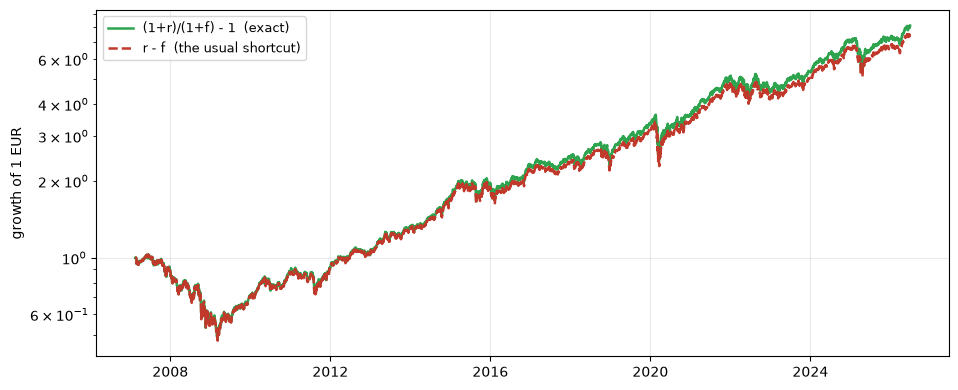

terminal difference: +7.82% over 19 years


In [3]:
# the difference between the exact form and the usual approximation, compounded
n = len(asset)
k = list(fx_rets)[0]
f = fx_rets[k]
exact = st.convert_return(asset, f)
naive = (asset - f).reindex(exact.index)
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(exact.index, (1 + exact).cumprod(), lw=1.8, color="#2ea44f",
        label="(1+r)/(1+f) - 1  (exact)")
ax.plot(naive.index, (1 + naive).cumprod(), lw=1.8, ls="--", color="#c0392b",
        label="r - f  (the usual shortcut)")
ax.set_yscale("log"); ax.set_ylabel(f"growth of 1 {k}"); ax.legend(fontsize=9)
plt.show()
print(f"terminal difference: {(1 + exact).prod() / (1 + naive).prod() - 1:+.2%} over "
      f"{len(exact) / 252:.0f} years")

> \U0001F4A1 **In plain words.** The shortcut is fine for a day and wrong for a decade. Every
> conversion in this study uses the exact form.

## 3 · The teardown

### 3.1 The full table, with each investor's own cash rate

In [4]:
print(st.sharpe_by_currency(asset, fx_rets, usd_rf).round(4).to_string())
print()
print("implied local risk-free rates (annualised, from covered interest parity):")
for k, f in fx_rets.items():
    rf_l = st.implied_foreign_rate(f, usd_rf)
    print(f"  {k}: {rf_l.mean() * 252:.2%}   vs USD {usd_rf.mean() * 252:.2%}")

             n   cagr    vol  rf_ann  excess_ann  sharpe  sharpe_arithmetic  max_dd    skew
currency                                                                                   
USD       4874 0.1089 0.1969  0.0134      0.1094  0.4554             0.5539 -0.5519 -0.0018
EUR       4874 0.1144 0.1961  0.0229      0.1046  0.4346             0.5332 -0.5364 -0.0738
GBP       4874 0.1230 0.1913  0.0271      0.1073  0.4651             0.5606 -0.3919  0.1368
JPY       4874 0.1310 0.2476  0.0310      0.1228  0.3714             0.4959 -0.6306 -0.0096
CHF       4874 0.0901 0.2217  0.0090      0.1020  0.3479             0.4598 -0.5780 -0.1309
AUD       4874 0.0959 0.1638  0.0193      0.0858  0.4413             0.5236 -0.4695 -0.1220
CAD       4874 0.1142 0.1721  0.0217      0.1012  0.5021             0.5880 -0.4886  0.1531



implied local risk-free rates (annualised, from covered interest parity):
  EUR: 2.42%   vs USD 1.34%
  GBP: 2.85%   vs USD 1.34%
  JPY: 3.27%   vs USD 1.34%
  CHF: 0.95%   vs USD 1.34%
  AUD: 2.03%   vs USD 1.34%
  CAD: 2.29%   vs USD 1.34%


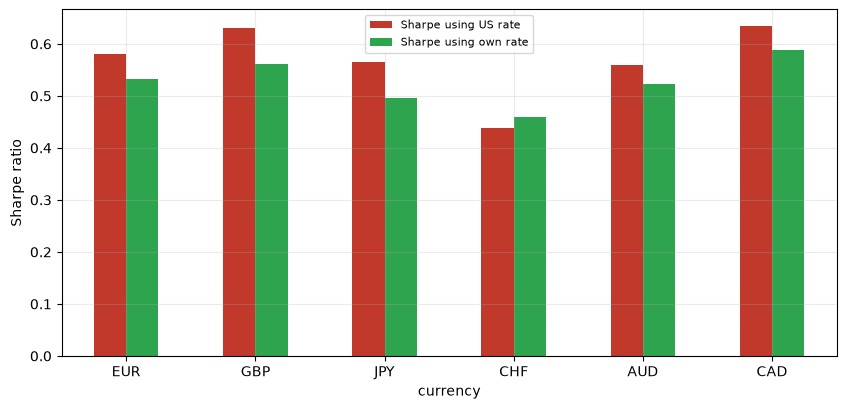

,Sharpe using US rate,Sharpe using own rate,error from the shortcut
currency,,,
EUR,0.5804,0.5332,0.0471
GBP,0.6305,0.5606,0.0699
JPY,0.5657,0.4959,0.0699
CHF,0.4388,0.4598,-0.0210
AUD,0.5585,0.5236,0.0348
CAD,0.6345,0.5880,0.0465


In [5]:
# how much the rate correction alone is worth
rows = []
for k, f in fx_rets.items():
    conv = st.convert_return(asset, f)
    loc = st.implied_foreign_rate(f, usd_rf).reindex(conv.index).fillna(0.0)
    usd = usd_rf.reindex(conv.index).fillna(0.0)
    rows.append({"currency": k,
                 "Sharpe using US rate": st.sharpe(conv - usd),
                 "Sharpe using own rate": st.sharpe(conv - loc)})
d = pd.DataFrame(rows).set_index("currency")
d["error from the shortcut"] = d["Sharpe using US rate"] - d["Sharpe using own rate"]
fig, ax = plt.subplots(figsize=(10, 4.5))
d[["Sharpe using US rate", "Sharpe using own rate"]].plot.bar(ax=ax,
                                                              color=["#c0392b", "#2ea44f"])
ax.set_ylabel("Sharpe ratio"); ax.legend(fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=0)
plt.show()
d.round(4)

### 3.2 The variance identity, checked

            corr  var_asset  var_fx     cov  predicted_var  realised_var  vol_ratio  approximation_error
currency                                                                                                
EUR       0.2350     0.0002  0.0000  0.0000         0.0002        0.0002     0.9963              -0.0000
GBP       0.3008     0.0002  0.0000  0.0000         0.0001        0.0001     0.9715               0.0000
JPY      -0.3115     0.0002  0.0000 -0.0000         0.0002        0.0002     1.2576              -0.0000
CHF       0.0004     0.0002  0.0000  0.0000         0.0002        0.0002     1.1262              -0.0000
AUD       0.5615     0.0002  0.0001  0.0001         0.0001        0.0001     0.8320               0.0000
CAD       0.4887     0.0002  0.0000  0.0000         0.0001        0.0001     0.8742               0.0000


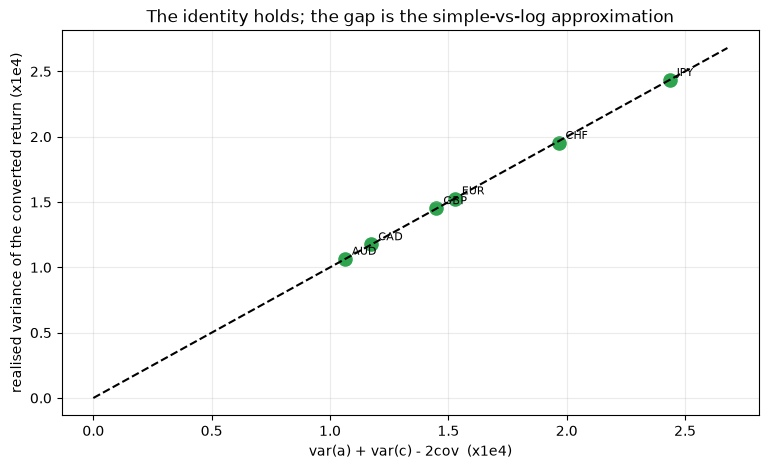

In [6]:
rows = []
for k, f in fx_rets.items():
    d = st.variance_decomposition(asset, f)
    rows.append({"currency": k, **{kk: d[kk] for kk in
                 ("corr", "var_asset", "var_fx", "cov", "predicted_var", "realised_var",
                  "vol_ratio", "approximation_error")}})
d = pd.DataFrame(rows).set_index("currency")
print(d.round(8).to_string())
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(d["predicted_var"] * 1e4, d["realised_var"] * 1e4, s=90, color="#2ea44f")
lim = [0, max(d["realised_var"].max(), d["predicted_var"].max()) * 1e4 * 1.1]
ax.plot(lim, lim, "k--", lw=1.5)
for cur, r in d.iterrows():
    ax.annotate(cur, (r["predicted_var"] * 1e4, r["realised_var"] * 1e4), fontsize=8,
                xytext=(5, 3), textcoords="offset points")
ax.set_xlabel("var(a) + var(c) - 2cov  (x1e4)")
ax.set_ylabel("realised variance of the converted return (x1e4)")
ax.set_title("The identity holds; the gap is the simple-vs-log approximation")
plt.show()

### 3.3 The three-way decomposition

In [7]:
rows = []
for k, f in fx_rets.items():
    dd = st.decompose_sharpe_gap(asset, f, usd_rf)
    rows.append({"currency": k, **{kk: dd[kk] for kk in
                 ("sharpe_home", "sharpe_foreign", "gap", "drift_term", "variance_term",
                  "rate_term", "vol_ratio", "rate_gap_ann")}})
d = pd.DataFrame(rows).set_index("currency")
print(d.round(4).to_string())
print()
print(f"variance term: median {d['variance_term'].median():+.3f}, "
      f"{(d['variance_term'] < 0).sum()} of {len(d)} negative  <- systematic")
print(f"drift term:    median {d['drift_term'].median():+.3f}, "
      f"{(d['drift_term'] > 0).sum()} positive / {(d['drift_term'] < 0).sum()} negative "
      f"  <- coin flip")
print(f"rate term:     median {d['rate_term'].median():+.3f}")

          sharpe_home  sharpe_foreign     gap  drift_term  variance_term  rate_term  vol_ratio  rate_gap_ann
currency                                                                                                    
EUR            0.4554          0.4346 -0.0208      0.0238         0.0029    -0.0474     0.9938        0.0096
GBP            0.4554          0.4651  0.0097      0.0648         0.0152    -0.0703     0.9677        0.0137
JPY            0.4554          0.3714 -0.0840      0.0785        -0.0923    -0.0702     1.2542        0.0177
CHF            0.4554          0.3479 -0.1075     -0.0777        -0.0504     0.0206     1.1245       -0.0044
AUD            0.4554          0.4413 -0.0141     -0.0727         0.0936    -0.0350     0.8296        0.0059
CAD            0.4554          0.5021  0.0468      0.0259         0.0676    -0.0468     0.8707        0.0084

variance term: median +0.009, 2 of 6 negative  <- systematic
drift term:    median +0.025, 4 positive / 2 negative   <- coin fl

### 3.4 Ranking stability

       USD    EUR    GBP    JPY    CHF     AUD    CAD
SPY 0.4550 0.4350 0.4650 0.3710 0.3480  0.4410 0.5020
QQQ 0.6290 0.6070 0.6390 0.5300 0.5170  0.6300 0.6740
TLT 0.1140 0.0720 0.0900 0.1360 0.0270 -0.0020 0.0730
GLD 0.4170 0.4190 0.4200 0.4290 0.3670  0.3200 0.4120
EFA 0.1530 0.1480 0.1680 0.1370 0.0930  0.0980 0.1640

     USD  EUR  GBP  JPY  CHF  AUD  CAD
SPY    2    2    2    3    3    2    2
QQQ    1    1    1    1    1    1    1
TLT    5    5    5    5    5    5    5
GLD    3    3    3    2    2    3    3
EFA    4    4    4    4    4    4    4


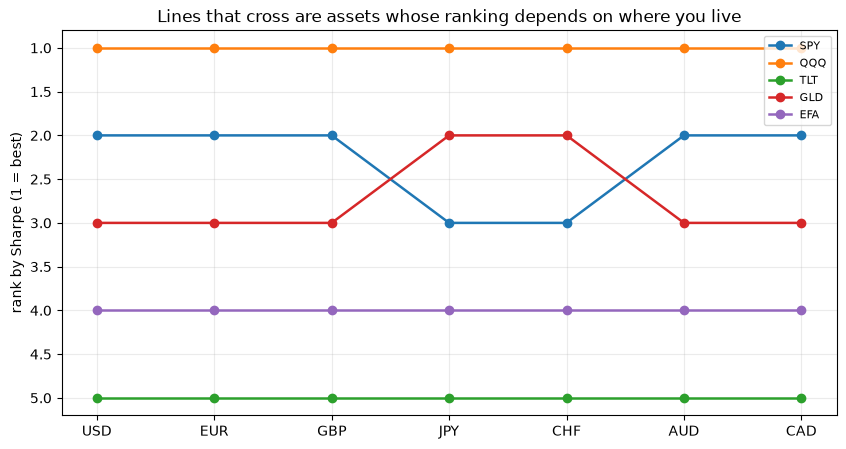

In [8]:
assets = {tk: rets[tk].reindex(asset.index).dropna()
          for tk in (data.ASSET,) + data.ALT_ASSETS if tk in rets.columns}
assets = {k: v for k, v in assets.items() if len(v) > 1000}
rank = st.ranking_stability(assets, fx_rets, usd_rf)
body = rank.drop("_rank_spread")
ranks = body.rank(ascending=False)
print(body.round(3).to_string())
print()
print(ranks.astype(int).to_string())
fig, ax = plt.subplots(figsize=(10, 5))
for a in body.index:
    ax.plot(range(len(body.columns)), ranks.loc[a], "o-", lw=1.8, ms=6, label=a)
ax.set_xticks(range(len(body.columns))); ax.set_xticklabels(body.columns)
ax.invert_yaxis(); ax.set_ylabel("rank by Sharpe (1 = best)")
ax.legend(fontsize=8)
ax.set_title("Lines that cross are assets whose ranking depends on where you live")
plt.show()

> \U0001F4A1 **In plain words.** Parallel lines would mean the currency shifts everything
> equally and an allocator can ignore it. Crossing lines mean "which fund has the better
> risk-adjusted return" genuinely has a different answer in different countries.

### 3.5 Hedging, with the carry

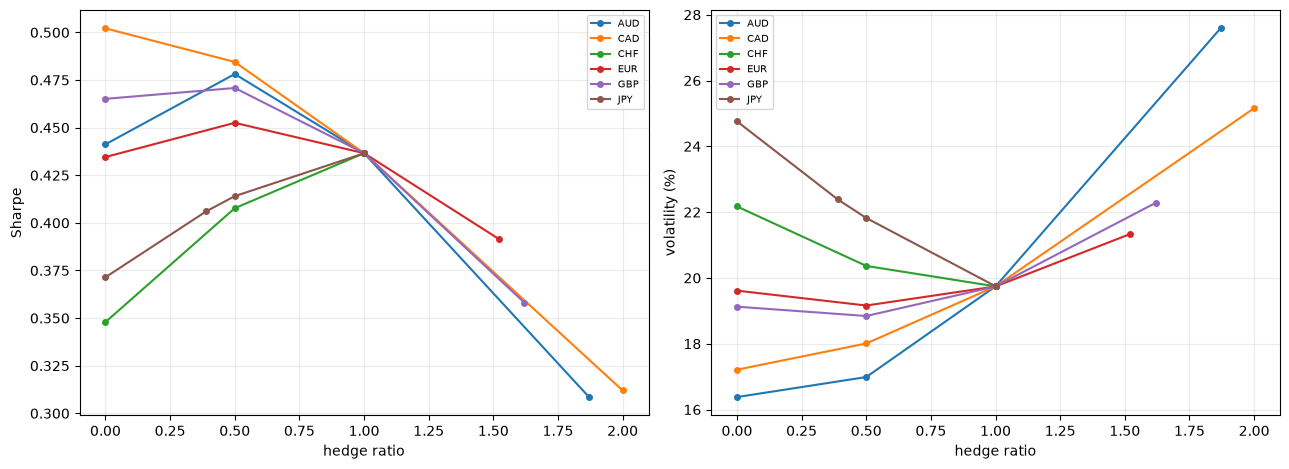

'currency  hedge_ratio  sharpe    vol   cagr\n     EUR       0.0000  0.4346 0.1961 0.1144\n     EUR       0.5000  0.4525 0.1916 0.1160\n     EUR       1.0000  0.4366 0.1974 0.1154\n     EUR       1.5200  0.3916 0.2133 0.1125\n     GBP       0.0000  0.4651 0.1913 0.1230\n     GBP       0.5000  0.4708 0.1884 0.1228\n     GBP       1.0000  0.4366 0.1974 0.1200\n     GBP       1.6200  0.3581 0.2229 0.1130\n     JPY       0.0000  0.3714 0.2476 0.1310\n     JPY       0.3900  0.4061 0.2239 0.1298\n     JPY       0.5000  0.4140 0.2182 0.1292\n     JPY       1.0000  0.4365 0.1975 0.1245\n     CHF       0.0000  0.3479 0.2217 0.0901\n     CHF       0.5000  0.4077 0.2036 0.0965\n     CHF       1.0000  0.4366 0.1974 0.0999\n     CHF       1.0000  0.4366 0.1974 0.0999\n     AUD       0.0000  0.4413 0.1638 0.0959\n     AUD       0.5000  0.4782 0.1699 0.1058\n     AUD       1.0000  0.4366 0.1974 0.1113\n     AUD       1.8700  0.3085 0.2759 0.1101\n     CAD       0.0000  0.5021 0.1721 0.1142\n     CAD 

In [9]:
rows = []
for k, f in fx_rets.items():
    ha = st.hedge_analysis(asset, f, usd_rf, cost_bps=3.0)
    for hr, row in ha["table"].iterrows():
        rows.append({"currency": k, "hedge_ratio": round(float(hr), 2),
                     "sharpe": row["sharpe"], "vol": row["vol"], "cagr": row["cagr"]})
d = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for cur, g in d.groupby("currency"):
    g = g.sort_values("hedge_ratio")
    axes[0].plot(g["hedge_ratio"], g["sharpe"], "o-", lw=1.5, ms=4, label=cur)
    axes[1].plot(g["hedge_ratio"], g["vol"] * 100, "o-", lw=1.5, ms=4, label=cur)
axes[0].set_xlabel("hedge ratio"); axes[0].set_ylabel("Sharpe"); axes[0].legend(fontsize=7)
axes[1].set_xlabel("hedge ratio"); axes[1].set_ylabel("volatility (%)")
axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()
d.round(4).to_string(index=False)

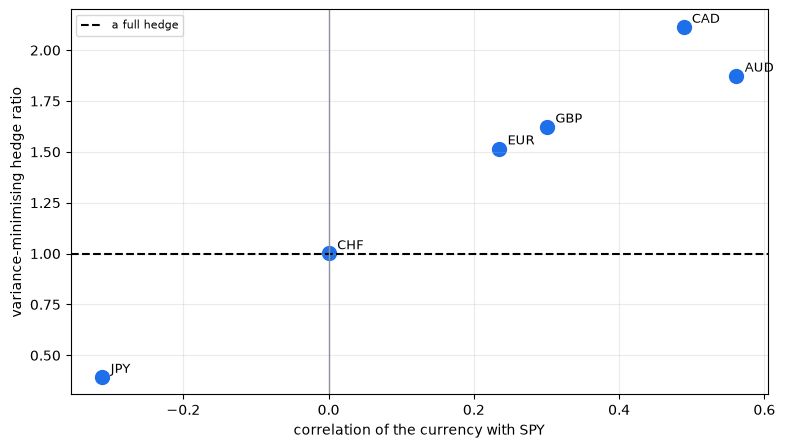

,corr with asset,optimal hedge ratio
currency,,
EUR,0.2350,1.5160
GBP,0.3010,1.6240
JPY,-0.3110,0.3930
CHF,0.0000,1.0010
AUD,0.5610,1.8740
CAD,0.4890,2.1140


In [10]:
rows = []
for k, f in fx_rets.items():
    h_star = st.hedge_ratio_that_minimises_variance(asset, f)
    corr = asset.reindex(f.index).corr(f)
    rows.append({"currency": k, "corr with asset": corr, "optimal hedge ratio": h_star})
d = pd.DataFrame(rows).set_index("currency")
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(d["corr with asset"], d["optimal hedge ratio"], s=100, color="#1f6feb")
for cur, r in d.iterrows():
    ax.annotate(cur, (r["corr with asset"], r["optimal hedge ratio"]), fontsize=9,
                xytext=(6, 3), textcoords="offset points")
ax.axhline(1.0, color="k", ls="--", lw=1.5, label="a full hedge")
ax.axvline(0, color="#8b949e", lw=1)
ax.set_xlabel(f"correlation of the currency with {data.ASSET}")
ax.set_ylabel("variance-minimising hedge ratio"); ax.legend(fontsize=8)
plt.show()
d.round(3)

### 3.6 Is it the window?

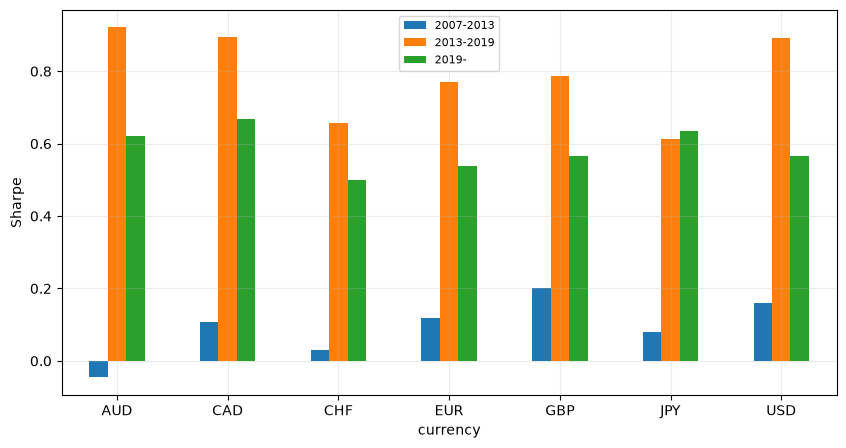

period    2007-2013  2013-2019  2019-
currency                             
AUD         -0.0460     0.9210 0.6200
CAD          0.1080     0.8940 0.6680
CHF          0.0310     0.6580 0.5000
EUR          0.1190     0.7700 0.5380
GBP          0.2020     0.7870 0.5650
JPY          0.0790     0.6120 0.6360
USD          0.1610     0.8930 0.5670

spread within each period: 2007-2013 0.25, 2013-2019 0.31, 2019- 0.17


In [11]:
rows = []
n = len(asset)
for label, sl in (("2007-2013", slice(0, n // 3)), ("2013-2019", slice(n // 3, 2 * n // 3)),
                  ("2019-", slice(2 * n // 3, n))):
    a2 = asset.iloc[sl]
    f2 = {k: v.reindex(a2.index).dropna() for k, v in fx_rets.items()}
    t2 = st.sharpe_by_currency(a2, f2, usd_rf.reindex(a2.index).fillna(0.0))
    for cur, r in t2.iterrows():
        rows.append({"period": label, "currency": cur, "sharpe": r["sharpe"]})
d = pd.DataFrame(rows)
piv = d.pivot(index="currency", columns="period", values="sharpe")
fig, ax = plt.subplots(figsize=(10, 5))
piv.plot.bar(ax=ax)
ax.set_ylabel("Sharpe"); ax.legend(fontsize=8, title="")
plt.setp(ax.get_xticklabels(), rotation=0)
plt.show()
print(piv.round(3).to_string())
print(f"\nspread within each period: "
      + ", ".join(f"{c} {piv[c].max() - piv[c].min():.2f}" for c in piv.columns))

### 3.7 Synthetic control

   corr  fx drift  rate gap     gap  drift term  variance term  rate term
-0.4000   -0.0300    0.0000 -0.0000      0.2120        -0.2120     0.0000
-0.4000   -0.0300    0.0300 -0.1360      0.2120        -0.2120    -0.1360
-0.4000    0.0000    0.0000 -0.1360      0.0760        -0.2120     0.0000
-0.4000    0.0000    0.0300 -0.2720      0.0760        -0.2120    -0.1360
-0.4000    0.0300    0.0000 -0.2720     -0.0600        -0.2120     0.0000
-0.4000    0.0300    0.0300 -0.4080     -0.0600        -0.2120    -0.1360
 0.0000   -0.0300    0.0000  0.1190      0.0930         0.0260     0.0000
 0.0000   -0.0300    0.0300 -0.0390      0.0930         0.0260    -0.1580
 0.0000    0.0000    0.0000 -0.0390     -0.0650         0.0260     0.0000
 0.0000    0.0000    0.0300 -0.1970     -0.0650         0.0260    -0.1580
 0.0000    0.0300    0.0000 -0.1970     -0.2230         0.0260     0.0000
 0.0000    0.0300    0.0300 -0.3560     -0.2230         0.0260    -0.1580
 0.4000   -0.0300    0.0000  0.0080   

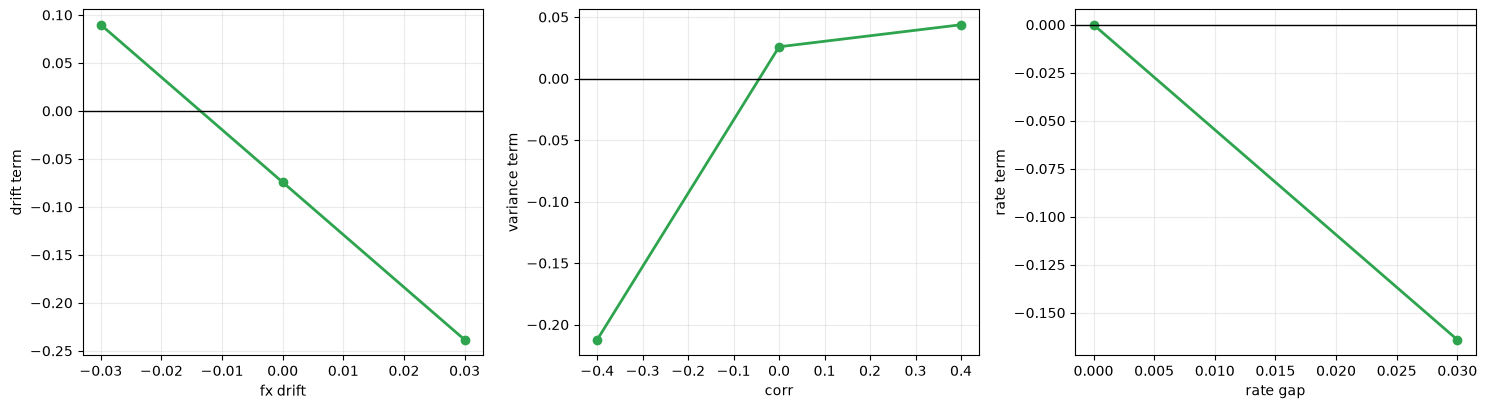

In [12]:
rows = []
for corr in (-0.4, 0.0, 0.4):
    for drift in (-0.03, 0.0, 0.03):
        for gap in (0.0, 0.03):
            w = st.synthetic_world(n=8000, corr=corr, fx_drift=drift, rate_gap=gap)
            dd = st.decompose_sharpe_gap(w["asset"], w["fx"], w["usd_rf"], w["local_rf"])
            rows.append({"corr": corr, "fx drift": drift, "rate gap": gap,
                         "gap": dd["gap"], "drift term": dd["drift_term"],
                         "variance term": dd["variance_term"], "rate term": dd["rate_term"]})
d = pd.DataFrame(rows)
print(d.round(3).to_string(index=False))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (driver, term) in zip(axes, (("fx drift", "drift term"),
                                     ("corr", "variance term"),
                                     ("rate gap", "rate term"))):
    g = d.groupby(driver)[term].mean()
    ax.plot(g.index, g.values, "o-", lw=2, color="#2ea44f")
    ax.axhline(0, color="k", lw=1)
    ax.set_xlabel(driver); ax.set_ylabel(term)
plt.tight_layout(); plt.show()

> \U0001F4A1 **In plain words.** Each panel varies one driver and plots the term it should move.
> All three slope the right way, which is the evidence that the decomposition is attributing
> correctly rather than shuffling numbers between columns.

## 4 · The verdict

In [13]:
tbl = st.sharpe_by_currency(asset, fx_rets, usd_rf)
rank = st.ranking_stability(assets, fx_rets, usd_rf)
gains = [st.hedge_analysis(asset, f, usd_rf, cost_bps=3.0)["sharpe_gain"]
         for f in fx_rets.values()]
ratios = [st.hedge_ratio_that_minimises_variance(asset, f) for f in fx_rets.values()]
pd.DataFrame({
    "Sharpe, US investor": [tbl.loc["USD", "sharpe"]],
    "Sharpe, best home currency": [tbl["sharpe"].max()],
    "Sharpe, worst home currency": [tbl["sharpe"].min()],
    "spread": [tbl["sharpe"].max() - tbl["sharpe"].min()],
    "median volatility increase": [
        tbl.drop("USD")["vol"].median() / tbl.loc["USD", "vol"] - 1],
    "largest ranking move (places)": [rank.loc["_rank_spread"].iloc[0]],
    "share of currencies hedging helps": [float(np.mean([g > 0 for g in gains]))],
    "median optimal hedge ratio": [float(np.median(ratios))],
}).T.rename(columns={0: "value"}).round(4)

,value
"Sharpe, US investor",0.4554
"Sharpe, best home currency",0.5021
"Sharpe, worst home currency",0.3479
spread,0.1542
median volatility increase,-0.0161
largest ranking move (places),1.0000
share of currencies hedging helps,0.5000
median optimal hedge ratio,1.5699


## 5 · Going further

- **Observed rates, not implied ones.** The local risk-free rates here come from covered
  interest parity applied to ETF drift. Actual deposit rates (EURIBOR, SONIA, TONAR) would
  remove the largest approximation in the study — and CIP itself broke down after 2008 (Du,
  Tepper & Verdelhan 2018), which is exactly when the sample starts.
- **Portfolio-level hedging.** Campbell et al. (2010) solve for the hedge ratios of a whole
  portfolio jointly; doing it asset by asset, as here, ignores that currencies hedge each other.
- **Long horizons.** Froot (1993): real exchange rates mean-revert over decades, so a thirty-year
  holder faces far less currency risk than the daily volatility suggests. Measuring the variance
  ratio of the currency across horizons would quantify it.
- **Tax.** Currency gains are treated differently in all six jurisdictions and can dominate
  everything measured here.